# Create your Vision Chat Assistant with LLaVA

This Colab notebook accompanies the blog post [Create your Vision Chat Assistant with LLaVA](https://medium.com/p/610b02c3283e).

## Install and import dependencies

In [1]:
# !pip install git+https://github.com/haotian-liu/LLaVA.git@786aa6a19ea10edc6f574ad2e16276974e9aaa3a

In [2]:
import os
# 设置 Hugging Face 镜像源
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
from transformers import AutoTokenizer, BitsAndBytesConfig
from llava.model import LlavaLlamaForCausalLM
from llava.utils import disable_torch_init
from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN, DEFAULT_IM_START_TOKEN, DEFAULT_IM_END_TOKEN
from llava.mm_utils import tokenizer_image_token, KeywordsStoppingCriteria
from llava.conversation import conv_templates, SeparatorStyle
import torch
from PIL import Image
import requests
from io import BytesIO


## Define the chatbot class


In [3]:
class LLaVAChatBot:
    def __init__(self,
                 model_path: str = 'liuhaotian/llava-v1.5-7b',
                 device_map: str = 'auto',
                 load_in_8_bit: bool = True,
                 **quant_kwargs) -> None:
        self.model = None
        self.tokenizer = None
        self.image_processor = None # 视觉编码器
        self.conv = None # 对话历史管理器
        self.conv_img = None # 当前对话的图像
        self.img_tensor = None # 处理后的图像张量
        self.roles = None
        self.stop_key = None
        self.load_models(model_path,
                         device_map=device_map,
                         load_in_8_bit=load_in_8_bit,
                         **quant_kwargs)
    # 加载模型
    def load_models(self, model_path: str,
                    device_map: str,
                    load_in_8_bit: bool,
                    **quant_kwargs) -> None:
        """加载模型,视觉编码器和分词器."""
        quant_cfg = BitsAndBytesConfig(**quant_kwargs) # 优化内存使用
        self.model = LlavaLlamaForCausalLM.from_pretrained(model_path,
                                                           low_cpu_mem_usage=True, # 优化了 CPU 内存使用
                                                           device_map=device_map,
                                                           load_in_8bit=load_in_8_bit,
                                                           quantization_config=quant_cfg)
        self.tokenizer = AutoTokenizer.from_pretrained(model_path,
                                                       use_fast=False)
        # 加载视觉编码器
        vision_tower = self.model.get_vision_tower() 
        vision_tower.load_model()
        vision_tower.to(device='cuda') # 分配到GPU
        self.image_processor = vision_tower.image_processor
        disable_torch_init()
    # 加载图片
    def setup_image(self, img_path: str) -> None:
        """加载并处理图像."""
        # 同时支持支持从本地路径或 HTTP/HTTPS URL 加载图像
        if img_path.startswith('http') or img_path.startswith('https'): # 网络图片
            response = requests.get(img_path)
            self.conv_img = Image.open(BytesIO(response.content)).convert('RGB')
        else:
            self.conv_img = Image.open(img_path).convert('RGB') # 本地图片
        self.img_tensor = self.image_processor.preprocess(self.conv_img,
                                                          return_tensors='pt'
                                                          )['pixel_values'].half().cuda()
        # .half() 将单精度(float32)转换为半精度(float16),可以加速计算,减小占用显存
    # 
    def generate_answer(self, **kwargs) -> str:
        """从当前对话中生成答案."""
        raw_prompt = self.conv.get_prompt()
        # 处理同时包含图像和文本的输入
        input_ids = tokenizer_image_token(raw_prompt,
                                          self.tokenizer,
                                          IMAGE_TOKEN_INDEX,
                                          return_tensors='pt').unsqueeze(0).cuda()
        # 设置停止条件
        stopping = KeywordsStoppingCriteria([self.stop_key],
                                            self.tokenizer,
                                            input_ids)
        with torch.inference_mode(): # 只推理,不计算梯度,可以减小现存占用,提升运算速度
            output_ids = self.model.generate(input_ids,
                                             images=self.img_tensor,
                                             stopping_criteria=[stopping],
                                             **kwargs)
        outputs = self.tokenizer.decode(
            # 切分,只保留答案,去掉prompt
            output_ids[0, input_ids.shape[1]:] 
        ).strip()
        self.conv.messages[-1][-1] = outputs # 更新对话历史
        
        return outputs.rsplit('</s>', 1)[0]

    def get_conv_text(self) -> str:
        """返回完整的对话文本."""
        return self.conv.get_prompt()

    # 开始新的对话
    def start_new_chat(self,
                       img_path: str,
                       prompt: str,
                       do_sample=True,
                       temperature=0.2,
                       max_new_tokens=1024,
                       use_cache=True,
                       **kwargs) -> str:
        """使用新的图片开始新的聊天."""
        conv_mode = "v1"
        self.setup_image(img_path)
        self.conv = conv_templates[conv_mode].copy()
        self.roles = self.conv.roles
        first_input = (DEFAULT_IM_START_TOKEN + DEFAULT_IMAGE_TOKEN +
                       DEFAULT_IM_END_TOKEN + '\n' + prompt)
        # 你的问题是 “这是什么？”，实际发给模型的是：<im_start><image><im_end> 这是什么？。
        # 问题:"请结合图片解释这个人在做什么",发给模型的就是:请结合<im_start><image><im_end> 解释这个人在做什么？
        # 问题:"请对比两张图片有什么不同",发给模型的就是:请对比<im_start><image><im_end>和<im_start><image><im_end>有什么不同?
        
        self.conv.append_message(self.roles[0], first_input)
        self.conv.append_message(self.roles[1], None)
        if self.conv.sep_style == SeparatorStyle.TWO:
            self.stop_key = self.conv.sep2
        else:
            self.stop_key = self.conv.sep
        answer = self.generate_answer(do_sample=do_sample,
                                      temperature=temperature,
                                      max_new_tokens=max_new_tokens,
                                      use_cache=use_cache,
                                      **kwargs)
        return answer

    def continue_chat(self,
                      prompt: str,
                      do_sample=True,
                      temperature=0.2,
                      max_new_tokens=1024,
                      use_cache=True,
                      **kwargs) -> str:
        """继续现有的聊天."""
        # if self.conv is None:
        #     raise RuntimeError("No existing conversation found. Start a new"
        #                        "conversation using the `start_new_chat` method.")
        if self.conv is None:
            raise RuntimeError("未找到现有对话。"
                               "请使用'start_new_chat'方法开始新的对话。")
        self.conv.append_message(self.roles[0], prompt)
        self.conv.append_message(self.roles[1], None)
        answer = self.generate_answer(do_sample=do_sample,
                                      temperature=temperature,
                                      max_new_tokens=max_new_tokens,
                                      use_cache=use_cache,
                                      **kwargs)
        return answer

## Setup the model

Download the model and set up the chatbot. It may take several minutes.

In [4]:
chatbot = LLaVAChatBot(load_in_8bit=True,
                       bnb_8bit_compute_dtype=torch.float16,
                       bnb_8bit_use_double_quant=True,
                       bnb_8bit_quant_type='nf8')

/root/autodl-tmp/conda-envs/llava_env/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

## Chat with the model

Example photo by Arnold Middelkoop on Unsplash.

In [5]:
# ans = chatbot.start_new_chat(img_path="https://images.unsplash.com/photo-1686577353812-6cbc7fce384b?q=80&w=1887&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
#                              prompt="Would the fish depicted in the image float if thrown in water? Think step by step.")
# ans = chatbot.start_new_chat(img_path="https://img.cc0.cn/pixabay/2019102400042748158.jpg!cc0.cn.jpg",
#                              prompt="图片里面的动物中国允许人工喂养吗?请进行思考")
ans = chatbot.start_new_chat(img_path="https://www.2008php.com/2011_Website_appreciate/11-01-26/20110126213231.jpg",
                             prompt="图片中有几只狗?")

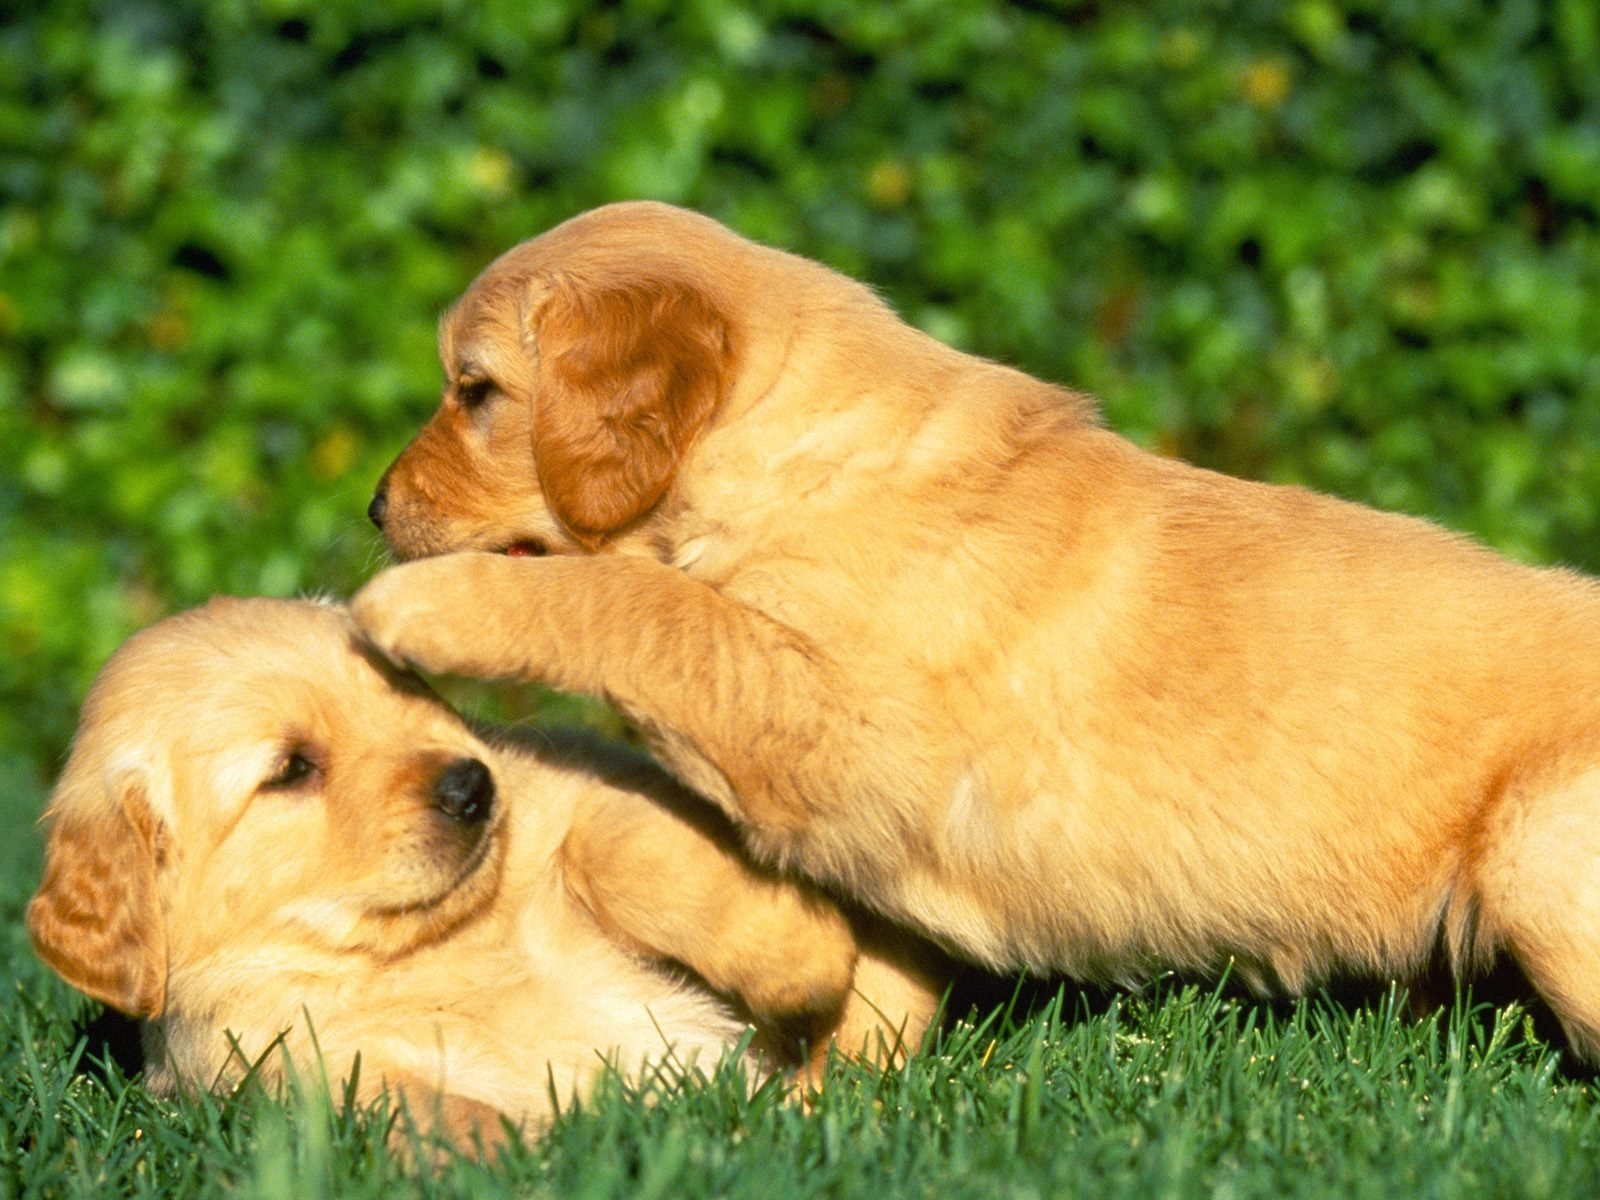

In [6]:
display(chatbot.conv_img)

In [7]:
print(ans)

在图片中，有两只狗。


In [8]:
# ans = chatbot.continue_chat("What material could be used to make a fish sculpture that floats on water?")
# ans = chatbot.continue_chat("中国允许人工喂养的动物,常见的有哪些,请说出五个")
ans = chatbot.continue_chat("这是什么品种的狗?")

In [9]:
print(ans)

这是黄色的黄 labrador retriever 狗。


Get the full conversation

In [10]:
print(chatbot.get_conv_text())

A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions. USER: <im_start><image><im_end>
图片中有几只狗? ASSISTANT: 在图片中，有两只狗。</s></s>USER: 这是什么品种的狗? ASSISTANT: 这是黄色的黄 labrador retriever 狗。</s></s>


In [11]:
print('恭喜🎉🎉,当你看到这里,说明,文件已经完成的运行了下来')

恭喜🎉🎉,当你看到这里,说明,文件已经完成的运行了下来
